

**Name:** Dibyanshu Ratna Bajracharya  
**ID:** 2408571  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/ArtificialIntelligenceandMachineLearning/week6/FruitinAmazon.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)
print(os.listdir(extract_path))

Mounted at /content/drive
Dataset extracted to: dataset
['FruitinAmazon']


---
# TASK 1 – Improved CNN with Data Augmentation, BatchNormalization & Dropout
## Task 1.1 – Explore and Clean Dataset

In [ ]:
import os

train_dir = os.path.join(extract_path, "FruitinAmazon", "train")
test_dir  = os.path.join(extract_path, "FruitinAmazon", "test")

# Get sorted class names
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
# ── Check Class Distribution ──────────────────────────────────────────────────
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [ ]:
# ── Check for Corrupted Images ────────────────────────────────────────────────
from PIL import Image, UnidentifiedImageError

corrupted_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


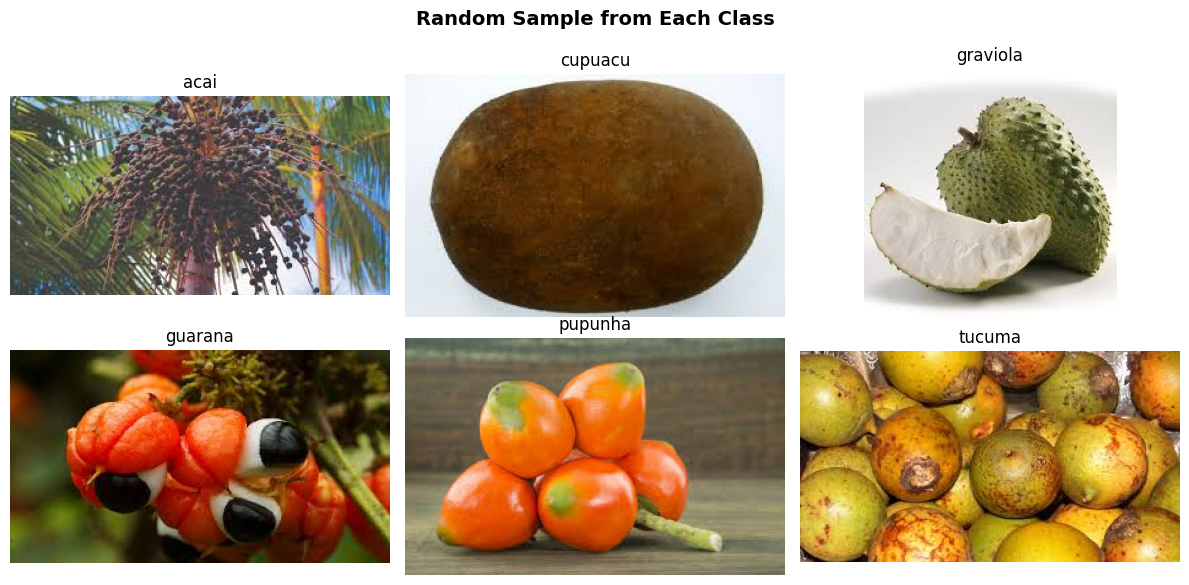

In [ ]:
# ── Visualize One Random Image per Class ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")
plt.suptitle("Random Sample from Each Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 1.2 – Data Loading & Augmentation (New Keras API)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

img_height, img_width = 128, 128
batch_size = 32
SEED = 42

# Load raw datasets (no rescaling here – rescaling is inside the model)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

print("Class names:", train_ds.class_names)

# Check batch shape
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Images shape: (32, 128, 128, 3)
Labels shape: (32,)


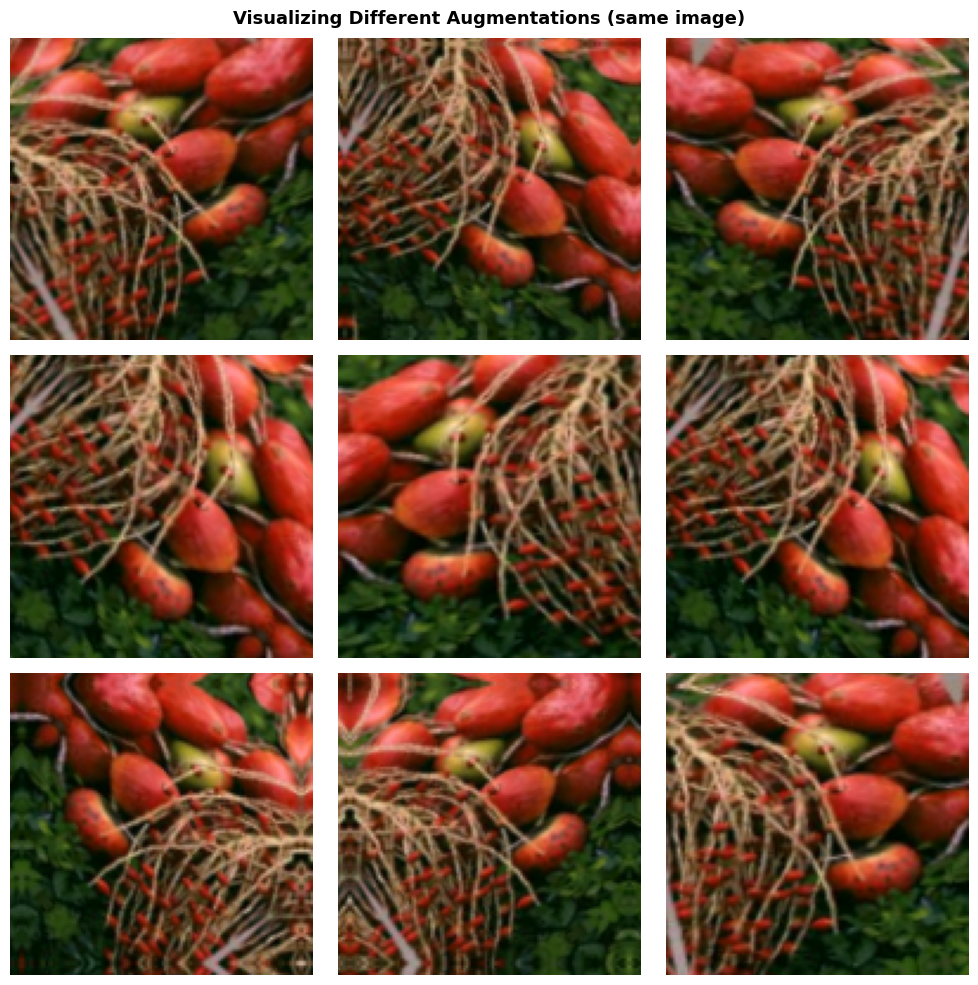

In [ ]:
# ── Data Augmentation using the NEW Keras API (tf.keras.layers.Random*) ───────
# This is applied INSIDE the model so it runs on GPU during training only.

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Visualize augmented versions of one image
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Visualizing Different Augmentations (same image)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Performance optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Task 1.3 – Build Improved CNN (with BatchNormalization & Dropout)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation,
    Rescaling, Lambda, Input
)

num_classes = len(class_names)
input_shape = (img_height, img_width, 3)

# ── Improved model with augmentation, BN, and Dropout built-in ───────────────
model = Sequential([
    Input(shape=input_shape),

    # Data Augmentation (only active during training)
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),

    # Rescaling (recommended: inside model for GPU acceleration)
    Rescaling(1./255),

    # ── Conv Block 1 ──────────────────────────────────────────────────────────
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 2 ──────────────────────────────────────────────────────────
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 3 ──────────────────────────────────────────────────────────
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Conv Block 4 ──────────────────────────────────────────────────────────
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── Fully Connected Layers ────────────────────────────────────────────────
    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── Output Layer ──────────────────────────────────────────────────────────
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 8,915,398 (34.01 MB)

 Trainable params: 8,912,902 (34.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

## Task 1.4 – Train the Improved Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1806 - loss: 2.1923 - val_accuracy: 0.4444 - val_loss: 1.7386 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3750 - loss: 1.6442 - val_accuracy: 0.7778 - val_loss: 1.5761 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4444 - loss: 1.4795 - val_accuracy: 0.2778 - val_loss: 1.5104 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5694 - loss: 1.2562 - val_accuracy: 0.3889 - val_loss: 1.3870 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.5556 - loss: 1.1873 - val_accuracy: 0.2222 - val_loss: 1.3517 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5833 - loss: 0.9642 - val_accuracy: 0.0000e+00 - val_loss: 1.4574 - learning_rate: 0.0010
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6250 - loss: 0.9790 - val_accuracy: 0.0000e+00 - va

## Task 1.5 – Evaluate the Improved Model

In [ ]:
# Load test dataset (raw pixels – model rescales internally)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

loss, acc = model.evaluate(test_ds)
print(f"\nImproved CNN – Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.2000 - loss: 1.9893

Improved CNN – Test Accuracy: 0.2000 (20.00%)


## Task 1.6 – Visualise Training Results

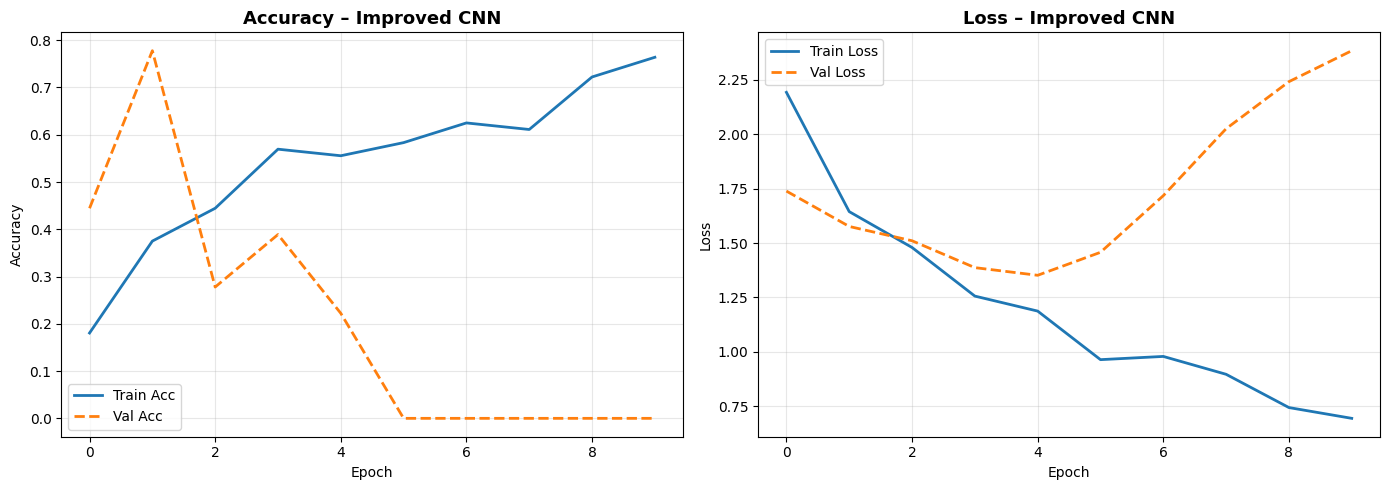

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
axes[0].set_title("Accuracy – Improved CNN", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[1].set_title("Loss – Improved CNN", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 1.7 – Predict on New Images

True class  : graviola
Image path  : dataset/FruitinAmazon/test/graviola/download (2).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
Predicted   : cupuacu  (confidence: 36.0%)


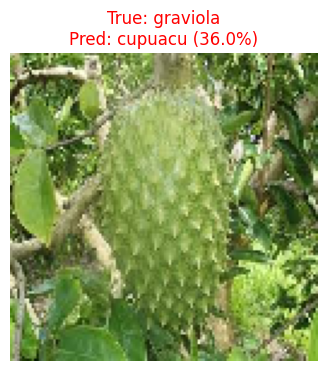

In [ ]:
import numpy as np

random_class = random.choice(class_names)
class_test_path = os.path.join(test_dir, random_class)
img_files = os.listdir(class_test_path)

if not img_files:
    raise ValueError(f"No images found in {class_test_path}")

img_filename = random.choice(img_files)
img_path = os.path.join(class_test_path, img_filename)

print(f"True class  : {random_class}")
print(f"Image path  : {img_path}")

img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)          # Raw pixels [0,255]
img_array = tf.expand_dims(img_array, 0)               # Add batch dim

predictions  = model.predict(img_array)
pred_class   = class_names[np.argmax(predictions)]
confidence   = np.max(predictions) * 100

print(f"Predicted   : {pred_class}  (confidence: {confidence:.1f}%)")

plt.figure(figsize=(4,4))
plt.imshow(img)
color = 'green' if pred_class == random_class else 'red'
plt.title(f"True: {random_class}\nPred: {pred_class} ({confidence:.1f}%)", color=color)
plt.axis('off')
plt.show()

---
# TASK 2 – Transfer Learning with VGG16
## Task 2.1 – Prepare Datasets for VGG16

In [ ]:
# VGG16 requires (224, 224) input
VGG_SIZE = (224, 224)

train_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=VGG_SIZE,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=SEED
)

val_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=VGG_SIZE,
    batch_size=batch_size,
    shuffle=False,
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

test_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=VGG_SIZE,
    batch_size=batch_size,
    shuffle=False
)

# VGG16 has its own preprocessing – apply it here
from tensorflow.keras.applications.vgg16 import preprocess_input

def vgg_preprocess(images, labels):
    return preprocess_input(images), labels

train_ds_vgg = train_ds_vgg.map(vgg_preprocess).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds_vgg   = val_ds_vgg.map(vgg_preprocess).cache().prefetch(AUTOTUNE)
test_ds_vgg  = test_ds_vgg.map(vgg_preprocess).prefetch(AUTOTUNE)

print("VGG16 datasets ready.")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
VGG16 datasets ready.


## Task 2.2 – Load VGG16 & Freeze Base Layers

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Step 1: Load pre-trained VGG16 without the top classification layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Step 2: Freeze all base model layers
base_model.trainable = False

frozen_count = sum(1 for layer in base_model.layers if not layer.trainable)
print(f"Frozen layers  : {frozen_count}")
print(f"Total params   : {base_model.count_params():,}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Frozen layers  : 19
Total params   : 14,714,688


## Task 2.3 – Add Custom Classification Head

In [ ]:
# Step 3: Add custom layers on top of frozen VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x)           # Reduces (7,7,512) → (512,)
x = Dense(1024, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

# Step 4: Create the final model
vgg_model = Model(inputs=base_model.input, outputs=outputs)

# Step 5: Compile
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTrainable params (custom head only):")
print(f"  {sum(np.prod(v.shape) for v in vgg_model.trainable_variables):,}")
vgg_model.summary()


Trainable params (custom head only):
  791,814


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             

 Total params: 15,509,062 (59.16 MB)

 Trainable params: 791,814 (3.02 MB)

 Non-trainable params: 14,717,248 (56.14 MB)

## Task 2.4 – Train VGG16 (Frozen Base + Custom Head)

In [ ]:
from tensorflow.keras.layers import Activation

callbacks_vgg = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_vgg = vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=20,
    callbacks=callbacks_vgg
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 27s/step - accuracy: 0.1250 - loss: 2.4368 - val_accuracy: 0.0556 - val_loss: 11.9312 - learning_rate: 1.0000e-04
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 0.2500 - loss: 2.2274 - val_accuracy: 0.0556 - val_loss: 9.3092 - learning_rate: 1.0000e-04
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 19s/step - accuracy: 0.2778 - loss: 1.9840 - val_accuracy: 0.0556 - val_loss: 7.4895 - learning_rate: 1.0000e-04
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 25s/step - accuracy: 0.2361 - loss: 1.7945 - val_accuracy: 0.0556 - val_loss: 6.2342 - learning_rate: 1.0000e-04
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 0.4306 - loss: 1.5984 - val_accuracy: 0.0556 - val_loss: 5.0691 - learning_rate: 1.0000e-04
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 25s/step - accuracy: 0.4722 - loss: 1.3956 - val_accuracy: 0.0556 - val_loss: 4.2333 - learning_rate: 1.0000e-04
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 0.4861 - loss: 1.319

## Task 2.5 – Evaluate VGG16 on Test Set

In [ ]:
vgg_loss, vgg_acc = vgg_model.evaluate(test_ds_vgg)
print(f"\nVGG16 Transfer Learning – Test Accuracy: {vgg_acc:.4f} ({vgg_acc*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.7333 - loss: 0.7468

VGG16 Transfer Learning – Test Accuracy: 0.7333 (73.33%)


## Task 2.6 – Visualise VGG16 Training Curves

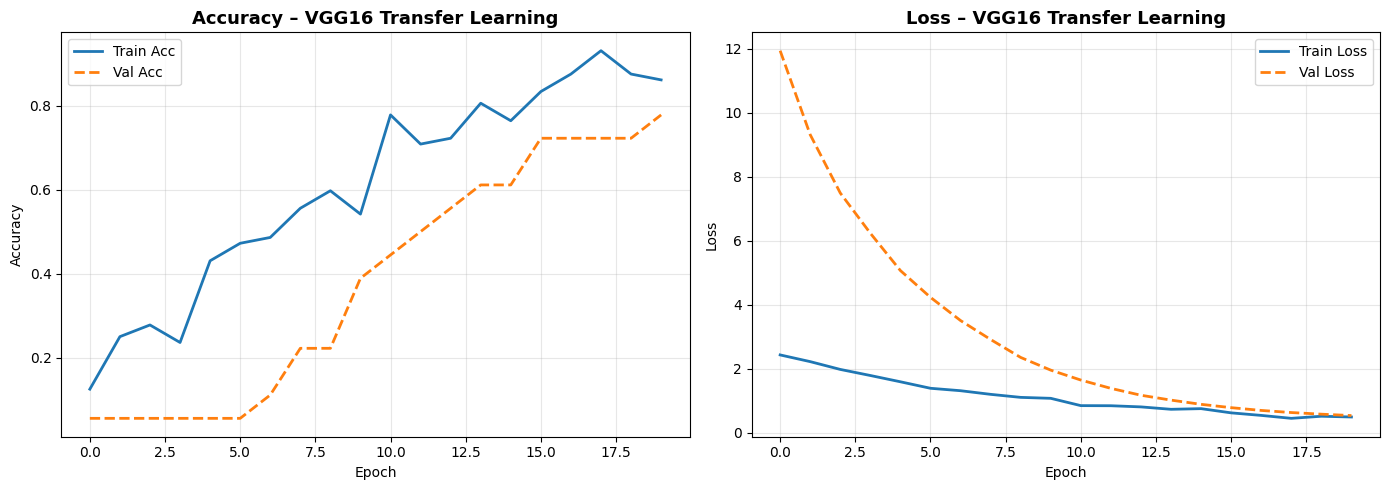

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg.history['accuracy'],     label='Train Acc',  linewidth=2)
axes[0].plot(history_vgg.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
axes[0].set_title("Accuracy – VGG16 Transfer Learning", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_vgg.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history_vgg.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[1].set_title("Loss – VGG16 Transfer Learning", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 2.7 – Inference Output & Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect true labels and predictions from test set
y_true = []
y_pred = []

for images, labels in test_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n── Classification Report (VGG16) ──────────────────────────")
print(classification_report(y_true, y_pred, target_names=class_names))


── Classification Report (VGG16) ──────────────────────────
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       1.00      0.40      0.57         5
    graviola       1.00      1.00      1.00         5
     guarana       0.80      0.80      0.80         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.73        30
   macro avg       0.78      0.73      0.73        30
weighted avg       0.78      0.73      0.73        30



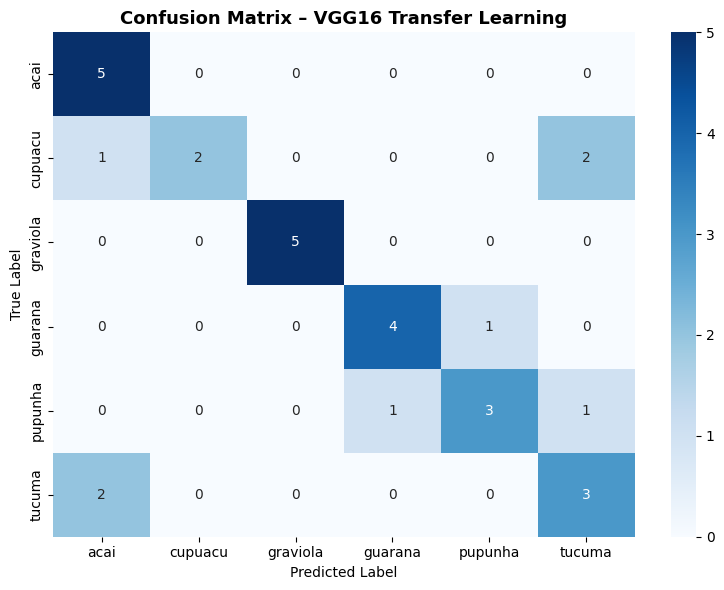

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix – VGG16 Transfer Learning", fontsize=13, fontweight='bold')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

True class  : graviola
Predicted   : graviola  (confidence: 83.3%)


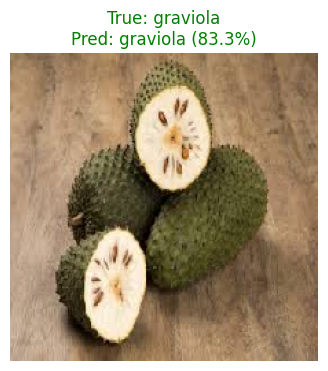

In [ ]:
# Predict on a random test image using VGG16
random_class_vgg = random.choice(class_names)
class_test_path_vgg = os.path.join(test_dir, random_class_vgg)
img_files_vgg = os.listdir(class_test_path_vgg)
img_path_vgg = os.path.join(class_test_path_vgg, random.choice(img_files_vgg))

img_vgg = tf.keras.utils.load_img(img_path_vgg, target_size=VGG_SIZE)
img_array_vgg = tf.keras.utils.img_to_array(img_vgg)
img_array_vgg = preprocess_input(tf.expand_dims(img_array_vgg, 0))

preds_vgg   = vgg_model.predict(img_array_vgg, verbose=0)
pred_vgg    = class_names[np.argmax(preds_vgg)]
conf_vgg    = np.max(preds_vgg) * 100

print(f"True class  : {random_class_vgg}")
print(f"Predicted   : {pred_vgg}  (confidence: {conf_vgg:.1f}%)")

plt.figure(figsize=(4, 4))
plt.imshow(img_vgg)
color = 'green' if pred_vgg == random_class_vgg else 'red'
plt.title(f"True: {random_class_vgg}\nPred: {pred_vgg} ({conf_vgg:.1f}%)", color=color)
plt.axis('off')
plt.show()